# Multi-particle directional velocity comparison

This notebook analyzes particle trajectories produced by the driven-colloid simulations. The workflow converts LAMMPS/OVITO trajectories into particle-level position and velocity data, groups velocity vectors by direction, aggregates repeated simulation runs, aligns equivalent angular responses, and examines the angular structure of the mean-speed signal in Fourier space.

The analysis focuses on **mobile particles (`type == 2`)**. Angular quantities describe the direction of the in-plane velocity vector, while speed magnitude is calculated from the x- and y-velocity components.


In [1]:
# pandas provides tabular particle-data handling and CSV input/output.
import pandas as pd
# NumPy provides numerical arrays, vectorized calculations, binning, and FFT operations.
import numpy as np
# Matplotlib is used to visualize angular distributions and Fourier power.
import matplotlib.pyplot as plt
import matplotlib as mpl
# OVITO reads the LAMMPS trajectory files generated by the simulations.
from ovito.io import import_file
# Reconstruct continuous particle paths across periodic boundaries before calculating displacement.
from ovito.modifiers import UnwrapTrajectoriesModifier


In [ ]:
# Allow complete DataFrame inspection during this trajectory-loading check.
pd.set_option("display.max_rows", None)

# Load one compressed LAMMPS trajectory into an OVITO pipeline.
pipe = import_file("C:/Users/olind/Documents/QuasiCrystalTono/ParquetFiles/Squares/MultiParticleSquare_1_300.lammpstrj.gz")

# Accumulate one particle-level pandas DataFrame for every stored trajectory frame.
frame = []
# Iterate through every simulation frame available in the trajectory.
for i in range(pipe.source.num_frames):
    # Read/compute the selected frame and expose its particle properties.
    data = pipe.compute(i)

    # Create one row per particle and label all rows with the current LAMMPS timestep.
    dataframe = pd.DataFrame({"frame": np.full(data.particles.count,data.attributes['Timestep'])})
    # Particle IDs allow individual particles to be followed across successive frames.
    dataframe["id"] = data.particles['Particle Identifier']
    # Store the population/type identifier for later particle selection.
    dataframe["type"] = data.particles['Particle Type']
    # Extract Cartesian particle coordinates from OVITO.
    dataframe["x"] = data.particles.positions[:,0]
    dataframe["y"] = data.particles.positions[:,1]
    dataframe["z"] = data.particles.positions[:,2]
    dataframe["timestep"] = data.attributes['Timestep']

    # Append the complete frame-level particle table to the list.
    frame.append(dataframe)

# Concatenate all frames vertically: one row now represents one particle at one frame.
Trj2= pd.concat(frame, ignore_index= True)
# Clean column labels by removing accidental leading/trailing whitespace.
Trj2.columns = Trj2.columns.str.strip()

# Make an explicit independent DataFrame copy before later manipulation.
Trj2 = Trj2.copy()
# Display the resulting long-form trajectory table for inspection.
print(Trj2)


RuntimeError: File does not exist: C:/Users/olind/Documents/QuasiCrystalTono/ParquetFiles/Squares/MultiParticleSquare_1_300.lammpstrj.gz

In [2]:

# Convert one LAMMPS trajectory into mobile-particle velocity directions and speed magnitudes.
# `dir` is the trajectory path; `dt` controls temporal subsampling and the finite-difference interval.
def VelValGen(dir, dt):

    pd.set_option("display.max_rows", None)

    # Load the requested trajectory into OVITO.
    pipe = import_file(dir)
    # Unwrap periodic-boundary crossings so they do not appear as artificial large displacements.
    pipe.modifiers.append(
    UnwrapTrajectoriesModifier()
    )

    # Collect particle-level data from every stored frame.
    frame = []
    # Iterate through the complete trajectory.
    for i in range(pipe.source.num_frames):
        data = pipe.compute(i)

        dataframe = pd.DataFrame({"frame": np.full(data.particles.count,data.attributes['Timestep'])})
        dataframe["id"] = data.particles['Particle Identifier']
        dataframe["type"] = data.particles['Particle Type']
        dataframe["x"] = data.particles.positions[:,0]
        dataframe["y"] = data.particles.positions[:,1]
        dataframe["z"] = data.particles.positions[:,2]
        dataframe["timestep"] = data.attributes['Timestep']

        frame.append(dataframe)

    # Combine frame-level tables into one long-form particle trajectory DataFrame.
    Trj2= pd.concat(frame, ignore_index= True)
    Trj2.columns = Trj2.columns.str.strip()

    Trj2 = Trj2.copy()
 
    # FILTERING: retain only type-2 particles, i.e. the mobile population.
    CleanData = Trj2[Trj2["type"] == 2].copy()
    # ORDERING: sort by particle ID and time so finite differences follow each individual trajectory.
    CleanData = CleanData.sort_values(["id","frame"])  # if you have frame

    #Using t = 1, so to get velocity its just the diff() of positions 
    # TEMPORAL SUBSAMPLING: within each particle ID, keep every `dt`-th observation.
    CleanData = CleanData[
    CleanData.groupby("id").cumcount() % dt == 0].reset_index(drop=True)

 
    # DIFFERENCING: calculate per-particle changes in x, y, and z between retained observations.
    vel = CleanData.groupby("id")[["x","y","z"]].diff()/dt
    # Store the calculated velocity components in the particle DataFrame.
    CleanData[["xVel","yVel","zVel"]] = vel

    # Remove the first undefined difference for each particle trajectory.
    CleanData.dropna(subset=["xVel","yVel","zVel"], inplace= True)


    
    # Calculate each mobile particle's in-plane speed magnitude sqrt(vx^2 + vy^2).
    mags = np.sqrt(CleanData["xVel"]**2 + CleanData["yVel"]**2)
    mean_mag = mags.mean()         


    # Mean x-component of the mobile-particle velocity.
    Xvalue = np.mean(CleanData["xVel"])
    # Mean y-component of the mobile-particle velocity.
    Yvalue = np.mean(CleanData["yVel"])

    # Convert each in-plane velocity vector to a direction in the circular interval [0, 360) degrees.
    angles = (np.degrees(np.arctan2(CleanData["yVel"], CleanData["xVel"])) + 360) % 360
    # Return aggregate components plus the per-observation angles and speed magnitudes used for binning.
    return Xvalue,Yvalue,mean_mag, angles, mags



# N7 quasiperiodic angular binning

For each quasiperiodic realization, this section combines mobile-particle velocity vectors from the complete driving-angle sweep. Velocity directions are divided into **2° bins**. For each bin the code tracks both the number of contributing observations and the sum of their speed magnitudes, allowing the mean speed for that velocity direction to be calculated.

The calculation is repeated independently for five runs and saved in long-form CSV format for later rotational alignment and ensemble averaging.


In [ ]:
#Some variable names are called N5 or differently, this does NOT mean it really is N5, it purely depends on the file it is reading

# Bin mobile-particle speeds by velocity direction for one quasiperiodic structure (`neigh`).
def N5Bins(neigh,dt):     
    # Extra no RAM
    # Angular-bin width in degrees.
    binsS = 2.0
    # Number of bins required to span the full 0-360 degree velocity-direction domain.
    numBins = int(360/binsS)

    # Store one mean-speed angular profile for each independent run.
    TotalspeedsN5 = []
    # Store the corresponding number of particle observations in each angular bin.
    TotalCounterN5 = []

    # Five independent simulation realizations are processed for each structure.
    listORuns = [1,2,3,4,5]
    for jj,j in enumerate(listORuns):
        # Integer histogram: number of velocity observations in each direction bin.
        counter = np.zeros(numBins, dtype= np.int64)
        # Floating-point accumulator: summed speed magnitude in each direction bin.
        speedN5 = np.zeros(numBins, dtype=np.float64)
        # Combine trajectories from the full applied-field sweep: 0° to 360° in 5° increments.
        for i in range(0,365,5):
            try:
                # Extract mobile-particle velocity directions and magnitudes from one trajectory.
                ListValQuasiN5 = VelValGen(f"D:/N7V2FR50/MPV2N7_Ne{neigh}_P25_R{j}_{i:03d}_FR50.lammpstrj.gz",dt)
            except Exception as e:
                print(f"error in D:/N7V2FR50/MPV2N7_Ne{neigh}_P25_R{j}_{i:03d}_FR50.lammpstrj.gz")
                continue

            # Array of per-observation velocity directions returned by VelValGen().
            angsN5 = ListValQuasiN5[3]
            # Matching array of per-observation in-plane speed magnitudes.
            spN5 = ListValQuasiN5[4]
            # BINNING: convert continuous angles to zero-based 2° bin indices.
            indexes = (angsN5 // binsS).astype(np.int32)
            indexes[indexes >= numBins] = numBins-1

            # Accumulate the number of particle observations falling in each angular bin.
            counter += np.bincount(indexes, minlength=numBins)
            # Accumulate the total speed magnitude contributed to each angular bin.
            speedN5 += np.bincount(indexes, weights=spN5, minlength=numBins)

        # Convert accumulated speed sums to mean speed per velocity-direction bin.
        meanSpeedN5 = speedN5 /counter
        # Mark empty bins as NaN because no mean speed is defined there.
        meanSpeedN5[counter == 0] = np.nan


        TotalspeedsN5.append(meanSpeedN5)
        TotalCounterN5.append(counter)

    # Physical angular coordinate at the center of every 2° bin.
    bin_centers = (np.arange(numBins) + 0.5) * binsS

    # Build a long-form table containing all run-level angular profiles.
    rows = []
    for run_id, (ms, ct) in enumerate(zip(TotalspeedsN5, TotalCounterN5), start=1):
        rows.append(pd.DataFrame({
            "run": run_id,
            "angle_deg": bin_centers,
            "mean_speed": ms,
            "counts": ct
        }))

    # Concatenate the run-level DataFrames into one analysis table.
    df_long = pd.concat(rows, ignore_index=True)

    # Save the processed angular-bin dataset for later alignment/averaging.
    df_long.to_csv(
        f"D:/N7V2FR50Analysis/BinsN7P25_Ne_{neigh}_FR50.csv",
        index=False
    )

# Repeat the binning workflow for quasiperiodic structures 1 through 10.
for i in range(1,11):
    # Use a temporal sampling interval dt = 1 for this dataset.
    N5Bins(i,1)


# Square reference system

This section applies the same velocity-direction binning method to the **square reference geometry**. Using the same representation—2° angular bins, mean speed, and observation counts—allows its directional response to be compared directly with the quasiperiodic datasets.


In [ ]:
# Apply the same angular velocity-binning procedure to the square reference simulations.
def N5Bins(dt):     

    # Width of each velocity-direction bin in degrees.
    binsS = 2.0
    # Total number of bins covering the 360° circular domain.
    numBins = int(360/binsS)

    # Store the mean-speed angular profile from each square-system run.
    TotalspeedsN5 = []
    # Store the corresponding angular-bin observation counts.
    TotalCounterN5 = []

    # Process 25 independent square-system realizations.
    for j in range(1,26):
        counter = np.zeros(numBins, dtype= np.int64)
        speedN5 = np.zeros(numBins, dtype=np.float64)
        # Combine the full 0°-360° driving-angle sweep for the current run.
        for i in range(0,365,5):
            try:
                # Extract mobile-particle velocity direction and magnitude from one trajectory.
                ListValQuasiN5 = VelValGen(f"D:/SquareV2/MPV2SQUARE_P25_R{j}_{i:03d}.lammpstrj.gz",dt)
            except Exception as e:
                print(f"error in D:/SquareV2/MPV2SQUARE_P25_R{j}_{i:03d}.lammpstrj.gz")
                continue

            angsN5 = ListValQuasiN5[3]
            spN5 = ListValQuasiN5[4]
            # Assign each velocity direction to its 2° angular bin.
            indexes = (angsN5 // binsS).astype(np.int32)
            indexes[indexes >= numBins] = numBins-1

            # Count observations in every angular bin.
            counter += np.bincount(indexes, minlength=numBins)
            # Sum their corresponding speed magnitudes within each bin.
            speedN5 += np.bincount(indexes, weights=spN5, minlength=numBins)

        # Calculate mean particle speed as a function of velocity direction.
        meanSpeedN5 = speedN5 /counter
        meanSpeedN5[counter == 0] = np.nan


        TotalspeedsN5.append(meanSpeedN5)
        TotalCounterN5.append(counter)

    # Determine the physical center angle of every bin.
    bin_centers = (np.arange(numBins) + 0.5) * binsS

    rows = []
    for run_id, (ms, ct) in enumerate(zip(TotalspeedsN5, TotalCounterN5), start=1):
        rows.append(pd.DataFrame({
            "run": run_id,
            "angle_deg": bin_centers,
            "mean_speed": ms,
            "counts": ct
        }))

    df_long = pd.concat(rows, ignore_index=True)

    # Save the square-reference angular distribution to CSV.
    df_long.to_csv(
        f"D:/SquareV2Analysis/BinsSquare_P25.csv",
        index=False
    )


# Execute the square-reference analysis with dt = 1.
N5Bins(1)


error in D:/SquareV2/MPV2SQUARE_P25_R1_000.lammpstrj.gz
error in D:/SquareV2/MPV2SQUARE_P25_R1_005.lammpstrj.gz
error in D:/SquareV2/MPV2SQUARE_P25_R1_010.lammpstrj.gz
error in D:/SquareV2/MPV2SQUARE_P25_R1_015.lammpstrj.gz
error in D:/SquareV2/MPV2SQUARE_P25_R1_020.lammpstrj.gz
error in D:/SquareV2/MPV2SQUARE_P25_R1_025.lammpstrj.gz
error in D:/SquareV2/MPV2SQUARE_P25_R1_030.lammpstrj.gz
error in D:/SquareV2/MPV2SQUARE_P25_R1_035.lammpstrj.gz
error in D:/SquareV2/MPV2SQUARE_P25_R1_040.lammpstrj.gz
error in D:/SquareV2/MPV2SQUARE_P25_R1_045.lammpstrj.gz
error in D:/SquareV2/MPV2SQUARE_P25_R1_050.lammpstrj.gz
error in D:/SquareV2/MPV2SQUARE_P25_R1_055.lammpstrj.gz
error in D:/SquareV2/MPV2SQUARE_P25_R1_060.lammpstrj.gz
error in D:/SquareV2/MPV2SQUARE_P25_R1_065.lammpstrj.gz
error in D:/SquareV2/MPV2SQUARE_P25_R1_070.lammpstrj.gz
error in D:/SquareV2/MPV2SQUARE_P25_R1_075.lammpstrj.gz
error in D:/SquareV2/MPV2SQUARE_P25_R1_080.lammpstrj.gz
error in D:/SquareV2/MPV2SQUARE_P25_R1_085.lammp

C:\Users\olind\AppData\Local\Temp\ipykernel_28648\685365519.py:27: RuntimeWarning: invalid value encountered in divide
  meanSpeedN5 = speedN5 /counter


# Rotational alignment, ensemble averaging, and angular Fourier analysis

Independent realizations can display the same directional pattern with a rotational offset. The functions below circularly shift each run relative to a reference profile before averaging. The particle-count arrays are shifted by the **same amount**, preserving the relationship between each mean-speed value and the number of observations contributing to it.

The final aligned mean-speed profile is also transformed with a real FFT. Because the signal is sampled around the full 360° domain, the Fourier-mode index can be interpreted as the number of repeated angular features/preferred directions in that profile.


In [13]:
# Examine repeated angular structure in a mean-speed profile using Fourier power.
def FPlots(shape,expected):
    # Remove the mean/DC level so the transform emphasizes angular variation.
    a = shape - np.mean(shape)

    # Real-valued FFT of the uniformly sampled angular signal.
    Fourier = np.fft.rfft(a)
    # Fourier amplitudes for each angular mode.
    amps = np.abs(Fourier)
    # Integer angular-mode indices.
    m = np.arange(len(amps))

    # Convert Fourier amplitudes to power.
    P = np.abs(Fourier)**2
    # Normalize by total non-zero-frequency power; the DC term is excluded.
    Pnorm = P / P[1:].sum()
    # Plot normalized angular power versus the number of repetitions around 360°.
    plt.plot(m,Pnorm)
    #plt.axvline(x = 10,color = "gray", linestyle = "--", label = "10 Angular repeats")
    # Mark the theoretically/structurally expected angular repetition mode.
    plt.axvline(x = expected,color = "red", linestyle = "--", label = f"Expected number of preferred directions ({expected})")
    plt.title("N7 1-4")
    plt.xlabel("Number of preferred directions")
    plt.ylabel("Normalized angular power")
    plt.legend()
    # Open a fresh figure for subsequent plotting.
    plt.figure()


180
180
180
180
180
180
180
180
180
180


'\nplt.axvline(x = 0,color = "gray", linestyle = "--")\nplt.axvline(x = 36,color = "gray", linestyle = "--")\nplt.axvline(x = 72,color = "gray", linestyle = "--")\nplt.axvline(x = 108,color = "gray", linestyle = "--")\nplt.axvline(x = 144,color = "gray", linestyle = "--")\nplt.axvline(x = 180,color = "gray", linestyle = "--")\nplt.axvline(x = 216,color = "gray", linestyle = "--")\nplt.axvline(x = 252,color = "gray", linestyle = "--")\nplt.axvline(x = 288,color = "gray", linestyle = "--")\nplt.axvline(x = 324,color = "gray", linestyle = "--")\n'

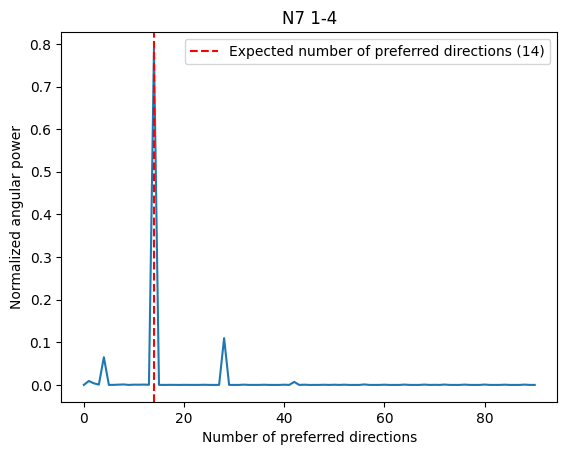

<Figure size 640x480 with 0 Axes>

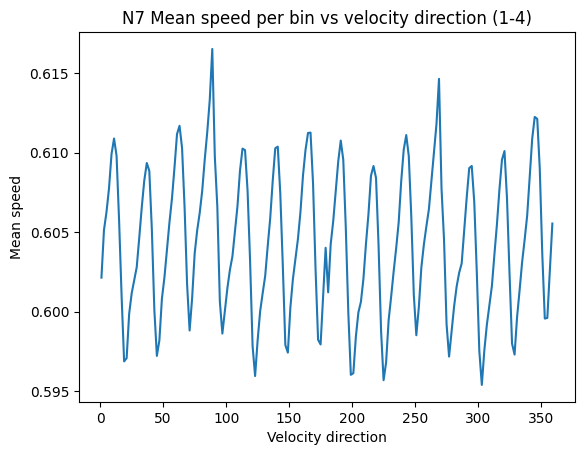

<Figure size 640x480 with 0 Axes>

In [ ]:
# Utility: convert a bracketed space-separated numeric string into a NumPy array.
def str_to_array(s):
    # remove brackets and split
    return np.fromstring(s.strip("[]"), sep=" ")

# Determine the circular shift that best aligns one angular profile with a reference profile.
def Rolling(refVal, Val,shift):
    # Mean-center the reference so alignment is based on profile shape rather than absolute level.
    ref = refVal - np.nanmean(refVal)
    # Initialize the best similarity score below any finite candidate value.
    bestP = -np.inf
    # Store the circular shift associated with the highest similarity.
    bestRoll = 0

    # Test each allowed positive circular shift.
    for i in range(0,shift):
        # Circularly rotate the candidate angular profile by i bins.
        roll = np.roll(Val,i)
        # Mean-center the shifted candidate profile.
        rollBase = roll - np.nanmean(roll)
        # NaN-aware dot product used as the profile-similarity/alignment score.
        point = np.nansum(ref*rollBase)

        if point > bestP:
            bestP = point
            bestRoll = i

    return bestRoll 


# Align repeated runs from the FR50/P25 dataset and calculate a count-weighted mean angular profile.
def multiNeigh(i,num):
    # Read the long-form per-run angular-bin dataset generated earlier.
    N5Read = pd.read_csv(f"D:/N{num}V2FR50Analysis/BinsN{num}P25_Ne_{i}_FR50.csv")
    #N5Read = pd.read_csv(f"D:/HexV2Analysis/BinsHex_P1.csv")
    # GROUPING: convert each run's mean-speed column into one NumPy angular-profile array.
    SpeedsN5  = [g["mean_speed"].to_numpy() for _, g in N5Read.groupby("run")]
    # Extract the matching angular-bin observation counts for every run.
    Counter5  = [g["counts"].to_numpy() for _, g in N5Read.groupby("run")]

    # Use run 1 to recover the shared angular-bin coordinates.
    bin_centers = N5Read[N5Read["run"]==1]["angle_deg"].to_numpy()


    # Use the first run as the rotational alignment reference.
    refVal = np.array(SpeedsN5[0])
    print(len(refVal))
    # Define the maximum number of circular-bin shifts tested by Rolling().
    shift = int(np.floor((360/10)/2)) +1
    # Initialize the aligned speed profiles with the unchanged reference run.
    NewTS = [refVal]
    # Keep the reference run's count distribution aligned with its speed profile.
    NewCounts = [Counter5[0]]
    for j in range(1,len(SpeedsN5)):
        # Find the circular shift that best aligns this run with the reference.
        roller = Rolling(refVal,SpeedsN5[j],shift)
        # Apply the selected shift to the mean-speed angular profile.
        NewTS.append(np.roll(SpeedsN5[j],roller))
        # Apply the identical shift to counts so weights remain attached to the correct bins.
        NewCounts.append(np.roll(Counter5[j], roller))


    # Stack aligned profiles into a 2D matrix: rows = runs, columns = angular bins.
    NewMat = np.vstack(NewTS) 
    # Stack aligned count arrays using the same shape.
    N = np.vstack(NewCounts) 

    # Weighted-mean numerator: sum(mean_speed × observation_count) for each bin.
    num = np.nansum(NewMat * N, axis=0)
    # Weighted-mean denominator: total observations contributing to each aligned bin.
    den = np.nansum(N, axis=0)

    # Also calculate the unweighted aligned mean; this value is not returned in the current code.
    MeanAligned = np.nanmean(NewMat, axis=0)

    Counts = np.vstack(NewCounts)
    # Sum observation counts across aligned runs for each angular direction.
    counts_sum = np.sum(Counts, axis=0)
    # Normalize counts to a relative angular-occurrence distribution summing to one.
    counts_sum = counts_sum / np.sum(counts_sum)
    # Final count-weighted mean speed; empty bins are retained as NaN.
    MeanAligned_pesos = np.divide(num, den, out=np.full_like(num, np.nan), where=den>0)

    return MeanAligned_pesos, bin_centers, counts_sum

# Same alignment/weighted-averaging method as multiNeigh(), but reading the alternate V2Analysis dataset.
def multiNeigh2(i,num):
    N5Read = pd.read_csv(f"D:/N{num}V2Analysis/BinsN{num}_Ne_{i}.csv")
    #N5Read = pd.read_csv(f"D:/SquareV2Analysis/BinsSquare_P1.csv")
    # GROUPING: convert each run's mean-speed column into one NumPy angular-profile array.
    SpeedsN5  = [g["mean_speed"].to_numpy() for _, g in N5Read.groupby("run")]
    # Extract the matching angular-bin observation counts for every run.
    Counter5  = [g["counts"].to_numpy() for _, g in N5Read.groupby("run")]

    # Use run 1 to recover the shared angular-bin coordinates.
    bin_centers = N5Read[N5Read["run"]==1]["angle_deg"].to_numpy()


    # Use the first run as the rotational alignment reference.
    refVal = np.array(SpeedsN5[0])
    print(len(refVal))
    # Define the maximum number of circular-bin shifts tested by Rolling().
    shift = int(np.floor((360/10)/2)) +1
    # Initialize the aligned speed profiles with the unchanged reference run.
    NewTS = [refVal]
    # Keep the reference run's count distribution aligned with its speed profile.
    NewCounts = [Counter5[0]]
    for j in range(1,len(SpeedsN5)):
        # Find the circular shift that best aligns this run with the reference.
        roller = Rolling(refVal,SpeedsN5[j],shift)
        # Apply the selected shift to the mean-speed angular profile.
        NewTS.append(np.roll(SpeedsN5[j],roller))
        # Apply the identical shift to counts so weights remain attached to the correct bins.
        NewCounts.append(np.roll(Counter5[j], roller))


    # Stack aligned profiles into a 2D matrix: rows = runs, columns = angular bins.
    NewMat = np.vstack(NewTS) 
    # Stack aligned count arrays using the same shape.
    N = np.vstack(NewCounts) 

    # Weighted-mean numerator: sum(mean_speed × observation_count) for each bin.
    num = np.nansum(NewMat * N, axis=0)
    # Weighted-mean denominator: total observations contributing to each aligned bin.
    den = np.nansum(N, axis=0)

    # Also calculate the unweighted aligned mean; this value is not returned in the current code.
    MeanAligned = np.nanmean(NewMat, axis=0)

    Counts = np.vstack(NewCounts)
    # Sum observation counts across aligned runs for each angular direction.
    counts_sum = np.sum(Counts, axis=0)
    # Normalize counts to a relative angular-occurrence distribution summing to one.
    counts_sum = counts_sum / np.sum(counts_sum)
    # Final count-weighted mean speed; empty bins are retained as NaN.
    MeanAligned_pesos = np.divide(num, den, out=np.full_like(num, np.nan), where=den>0)

    return MeanAligned_pesos, bin_centers, counts_sum





# Ensemble-average aligned FR50/P25 profiles across multiple quasiperiodic structures.
def folds(p,num):
    meanComplete = []
    countsComplete = []

    for i in range(1,p):
        no = multiNeigh(i,num)
        meanComplete.append(no[0])
        countsComplete.append(no[2])

    # Convert the list of equally sized angular profiles into a 2D NumPy array.
    meanComplete = np.stack(meanComplete)
    countsComplete = np.stack(countsComplete)

    # Average across structures independently for every angular bin.
    meanComplete = np.nanmean(meanComplete, axis = 0)
    countsComplete = np.nanmean(countsComplete, axis = 0)



    return countsComplete, meanComplete, no[1]

# Equivalent ensemble-averaging routine for the alternate V2Analysis dataset.
def folds2(p,num):
    meanComplete = []
    countsComplete = []

    for i in range(1,p):
        no = multiNeigh2(i,num)
        meanComplete.append(no[0])
        countsComplete.append(no[2])

    # Convert the list of equally sized angular profiles into a 2D NumPy array.
    meanComplete = np.stack(meanComplete)
    countsComplete = np.stack(countsComplete)

    # Average across structures independently for every angular bin.
    meanComplete = np.nanmean(meanComplete, axis = 0)
    countsComplete = np.nanmean(countsComplete, axis = 0)



    return countsComplete, meanComplete, no[1]



# Combine structures 1-10 for the N7 FR50/P25 dataset.
cc1, mc1, binsx1 = folds(11,7)
#You can plot counts (cc1) or mean (mc1), counts gives you simply the amount of data points overall that fall into the specific range,
# so when graphing cc1 you would say particles tend to move more in the directions indicated by the peaks, but it DOESNT mean necesarilly faster.
# When ploting mc1 you can read it as a peak in speed in that direction.
#
# 
#  
#cc2, mc2, binsx2 = folds2(11,7)
# Analyze the final mean-speed profile in Fourier space, marking mode 14 as the expected repetition.
FPlots(mc1,14)
plt.figure()
# Plot ensemble-averaged mean speed as a function of mobile-particle velocity direction.
plt.plot(binsx1,mc1)
#plt.plot(binsx2,mc2+0.2)
#plt.title("Number of occurences vs velocity direction (1-1)")
plt.title("N7 Mean speed per bin vs velocity direction (1-4)")
plt.xlabel("Velocity direction")
#plt.ylabel("Number of occurences")
plt.ylabel("Mean speed")
plt.figure()

'''
plt.axvline(x = 0,color = "gray", linestyle = "--")
plt.axvline(x = 36,color = "gray", linestyle = "--")
plt.axvline(x = 72,color = "gray", linestyle = "--")
plt.axvline(x = 108,color = "gray", linestyle = "--")
plt.axvline(x = 144,color = "gray", linestyle = "--")
plt.axvline(x = 180,color = "gray", linestyle = "--")
plt.axvline(x = 216,color = "gray", linestyle = "--")
plt.axvline(x = 252,color = "gray", linestyle = "--")
plt.axvline(x = 288,color = "gray", linestyle = "--")
plt.axvline(x = 324,color = "gray", linestyle = "--")
'''
